# Plant Disease — Local Training (Jupyter)

**Run from project root:** `D:\ML\plant-disease-detector`

Prerequisites:
1. Dataset at `data/PlantVillage/color/`
2. venv activated, `pip install -r requirements.txt jupyter`

In [1]:
# Cell 1 — Check paths & GPU
from pathlib import Path
import torch

ROOT = Path(r"D:/ML/plant-disease-detector")  # change if your path differs
DATA_DIR = ROOT / "data/PlantVillage/color"

print("Project root:", ROOT)
print("Data dir exists:", DATA_DIR.exists())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if DATA_DIR.exists():
    classes = [d.name for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]
    print(f"Found {len(classes)} class folders")
else:
    print("ERROR: Download dataset first — see Step 1 in docs")

Project root: D:\ML\plant-disease-detector
Data dir exists: True
PyTorch: 2.11.0+cu128
CUDA available: True
Found 38 class folders


In [4]:
# Cell 2 — EDA (class counts + chart)
%matplotlib inline
import sys
sys.path.insert(0, str(ROOT))

!cd /d "{ROOT}" && "{sys.executable}" -m scripts.eda

Total images: 8234
Classes: 8

Class distribution:
  Tomato — Late blight: 1909
  Tomato — healthy: 1591
  Potato — Early blight: 1000
  Potato — Late blight: 1000
  Tomato — Early blight: 1000
  Tomato — Leaf Mold: 952
  Apple — Apple scab: 630
  Potato — healthy: 152

Saved chart to D:\ML\plant-disease-detector\logs\class_distribution.png


In [6]:
# Cell 3 — TRAIN (uses src/train.py — same as terminal)
# Windows: set num_workers: 0 in config.yaml before running

!cd /d "{ROOT}" && "{sys.executable}" -m src.train

Using device: cuda
Samples -> train: 5763, val: 1235, test: 1236
Classes: 8
Epoch 01/10 | train loss 0.9186 acc 0.725 f1 0.663 | val loss 0.4678 acc 0.862 f1 0.847
  Saved best model to D:\ML\plant-disease-detector\models\plant_disease_resnet18.pt (val F1=0.8474)
Epoch 02/10 | train loss 0.4458 acc 0.873 f1 0.858 | val loss 0.3540 acc 0.887 f1 0.886
  Saved best model to D:\ML\plant-disease-detector\models\plant_disease_resnet18.pt (val F1=0.8861)
Epoch 03/10 | train loss 0.3411 acc 0.901 f1 0.900 | val loss 0.2740 acc 0.912 f1 0.911
  Saved best model to D:\ML\plant-disease-detector\models\plant_disease_resnet18.pt (val F1=0.9113)
Epoch 04/10 | train loss 0.3065 acc 0.906 f1 0.909 | val loss 0.2688 acc 0.908 f1 0.905
Epoch 5: unfreezing backbone for full fine-tuning
Epoch 05/10 | train loss 0.1526 acc 0.945 f1 0.943 | val loss 0.0769 acc 0.968 f1 0.975
  Saved best model to D:\ML\plant-disease-detector\models\plant_disease_resnet18.pt (val F1=0.9748)
Epoch 06/10 | train loss 0.0628 ac


100%|##########| 181/181 [00:48<00:00,  3.35it/s]
                                                 

100%|##########| 39/39 [00:07<00:00,  5.92it/s]
                                               

 99%|#########9| 180/181 [00:54<00:00,  3.49it/s]
                                                 

100%|##########| 39/39 [00:06<00:00,  7.06it/s]
                                               

 99%|#########9| 180/181 [00:54<00:00,  3.01it/s]
                                                 

100%|##########| 39/39 [00:06<00:00,  6.71it/s]
                                               

 99%|#########9| 180/181 [00:52<00:00,  3.43it/s]
                                                 

100%|##########| 39/39 [00:07<00:00,  6.38it/s]
                                               

100%|##########| 181/181 [01:12<00:00,  2.93it/s]
                                                 

 97%|#########7| 38/39 [00:06<00:00,  6.19it/s]
                                               

 99%|####

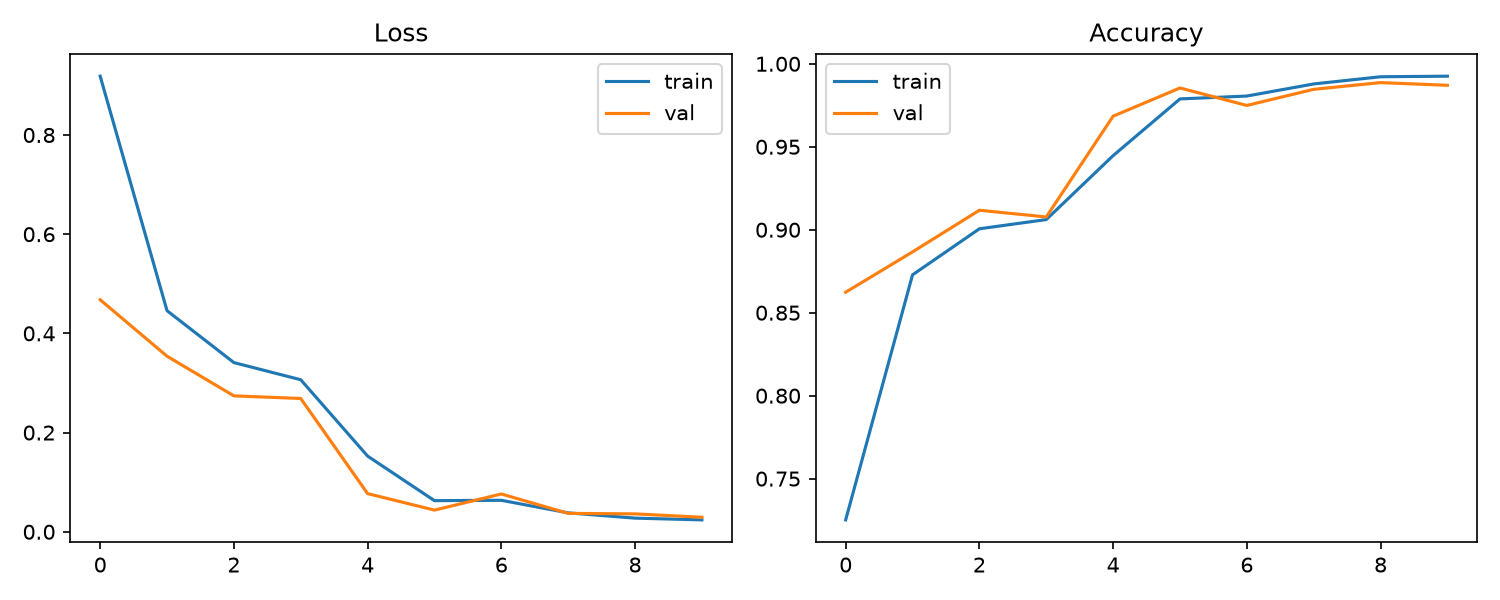

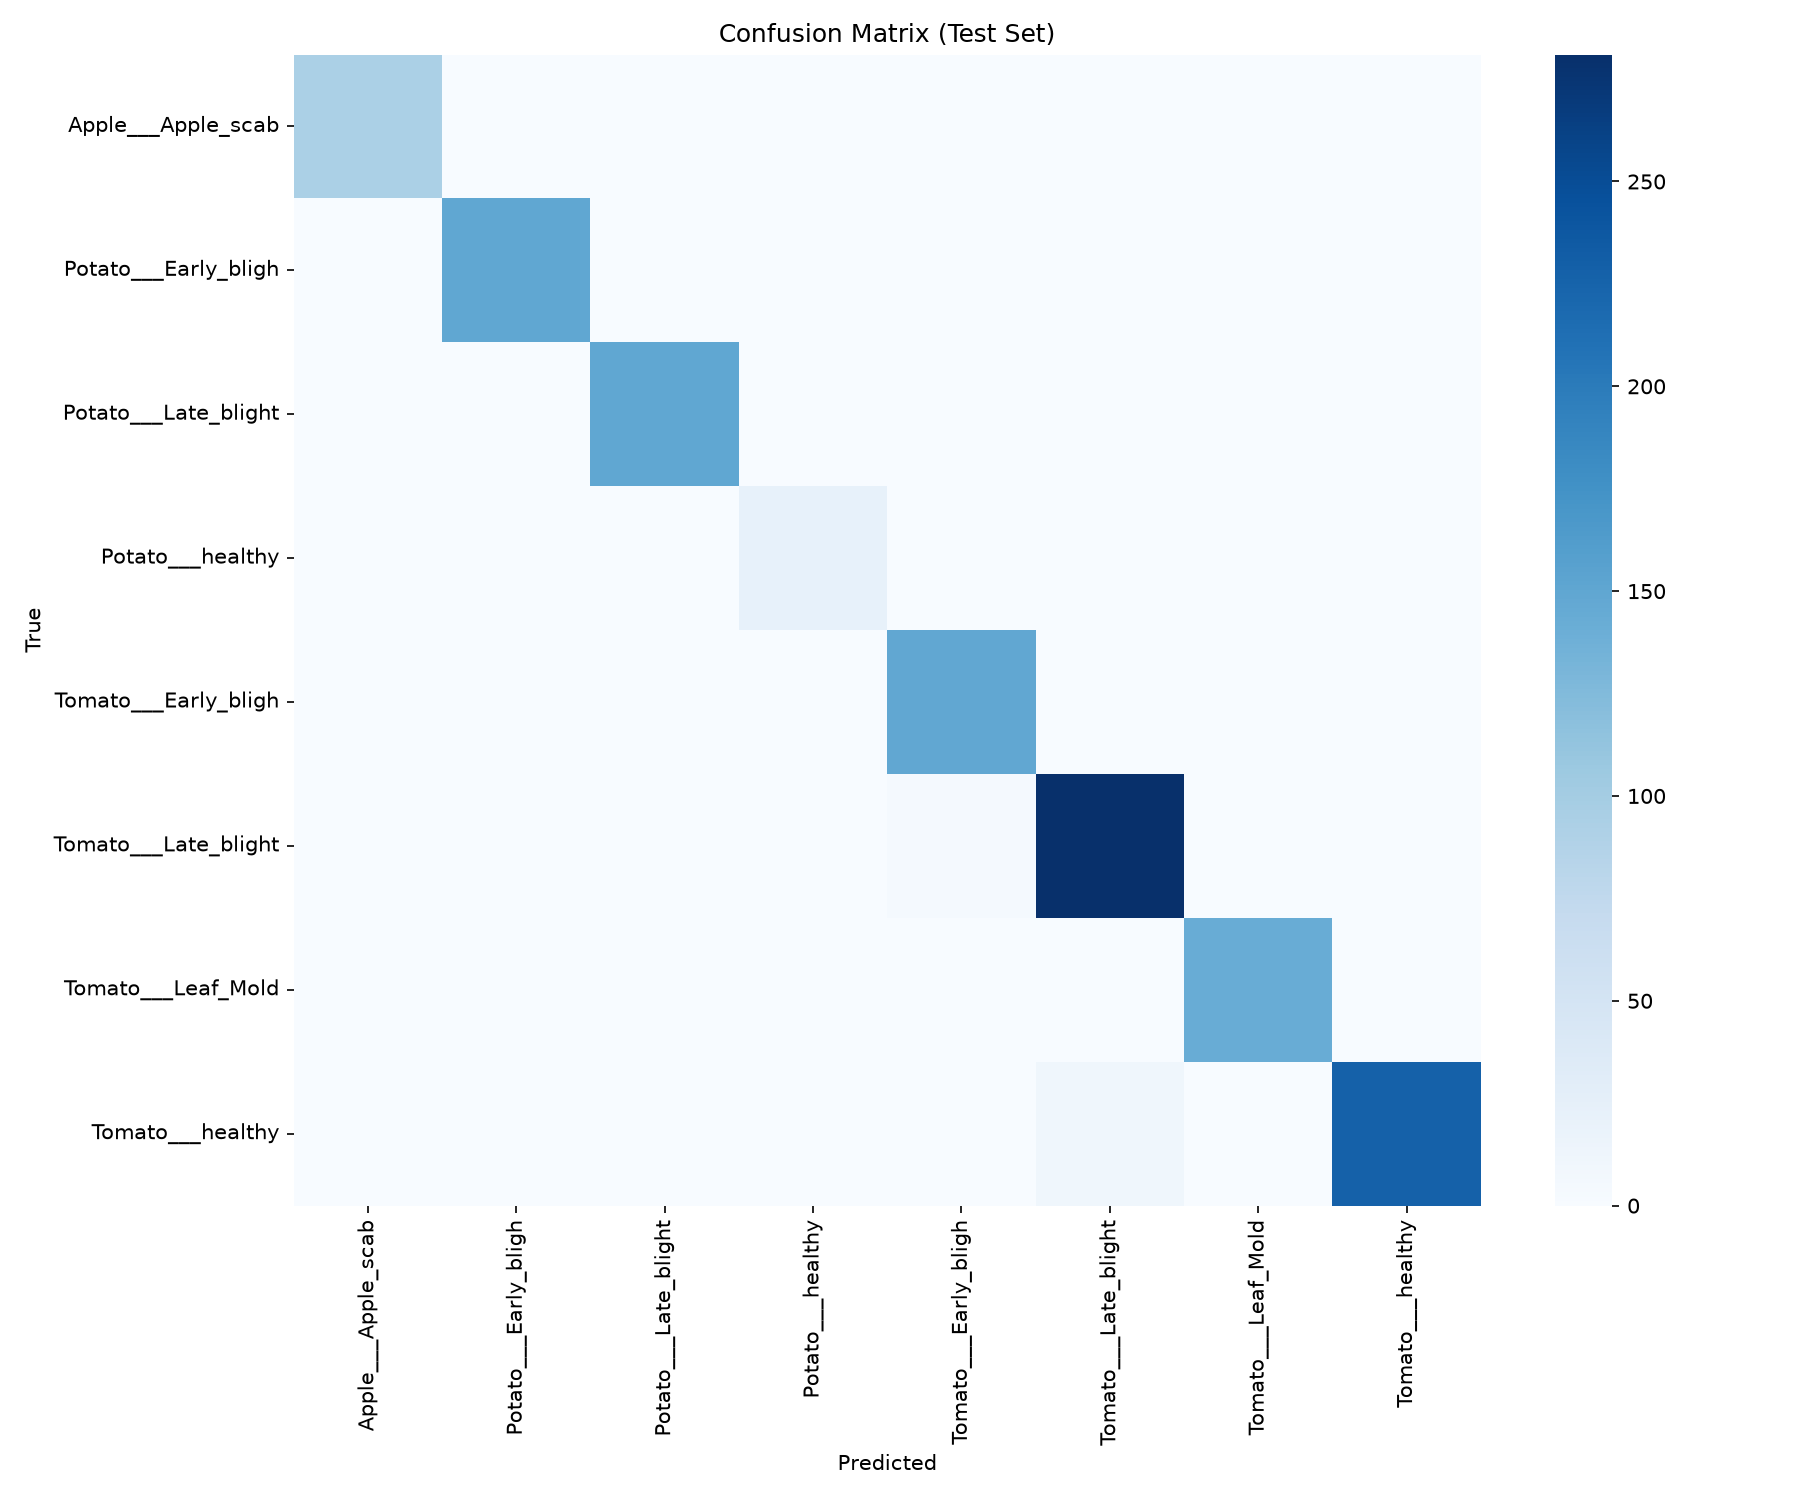

Test accuracy: 0.9854
Macro F1:        0.9904


In [7]:
# Cell 4 — Show results
from IPython.display import Image, display
import json

display(Image(filename=str(ROOT / "logs/training_curves.png")))
display(Image(filename=str(ROOT / "logs/confusion_matrix.png")))

with open(ROOT / "logs/test_metrics.json") as f:
    metrics = json.load(f)
print(f"Test accuracy: {metrics['test_accuracy']:.4f}")
print(f"Macro F1:        {metrics['test_macro_f1']:.4f}")